# HODA Digit Classification

A simple Deep Learning practice using Keras for handwritten digit classification.

## import librarys

In [34]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.layers import Dense, Dropout, Flatten, Softmax
from keras.models import Sequential
from scipy.io import loadmat
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

## Load and Prepare Dataset

Loading the HODA dataset and preparing the images for the model.

In [35]:
dataset = loadmat("dataset/Data_hoda_full.mat")

data = dataset["Data"][:5000]
labels = dataset["labels"][:5000]

data = np.squeeze(data)

data_14_by_14 = [
    cv.resize(img, (14, 14))
    for img in data
]

X = np.array(data_14_by_14)

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=.2, random_state=42
)

X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("X shape:", X.shape)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X shape: (5000, 14, 14)
X_train shape: (4000, 14, 14)
X_test shape: (1000, 14, 14)


## Build the Model

Building a simple neural network with Dense, ReLU and Dropout.

In [36]:
model = Sequential([
    Flatten(input_shape=(14, 14)),
    Dense(64, activation="relu"),
    Dropout(.2),
    Dense(10)
])

model.summary()

c:\Users\Amirkr\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 196)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        12,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,258 (51.79 KB)

 Trainable params: 13,258 (51.79 KB)

 Non-trainable params: 0 (0.00 B)

## Compile the Model

Setting the loss function, optimizer and accuracy metric.

In [37]:
model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer="rmsprop",
    metrics=["accuracy"]
)

## Train the Model

Training the model with 100 epochs and batch size 64.

In [38]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64,
    validation_split=.2
)

Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6278 - loss: 1.2873 - val_accuracy: 0.8725 - val_loss: 0.6017
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8516 - loss: 0.5383 - val_accuracy: 0.9112 - val_loss: 0.3455
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9025 - loss: 0.3616 - val_accuracy: 0.9250 - val_loss: 0.2591
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9234 - loss: 0.2764 - val_accuracy: 0.9337 - val_loss: 0.2193
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9334 - loss: 0.2285 - val_accuracy: 0.9413 - val_loss: 0.2007
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9450 - loss: 0.1978 - val_accuracy: 0.9388 - val_loss: 0.1927
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9491 - loss: 0.1781 - val_accuracy: 0.9475 - val_loss: 0.1827
Epoch 8/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1594 - val_accuracy: 0.9463 - v

## Test

Evaluating the model on the test data and checking the training and validation accuracy and loss.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9680 - loss: 0.1487 
accuracy : 0.97, loss : 0.1487


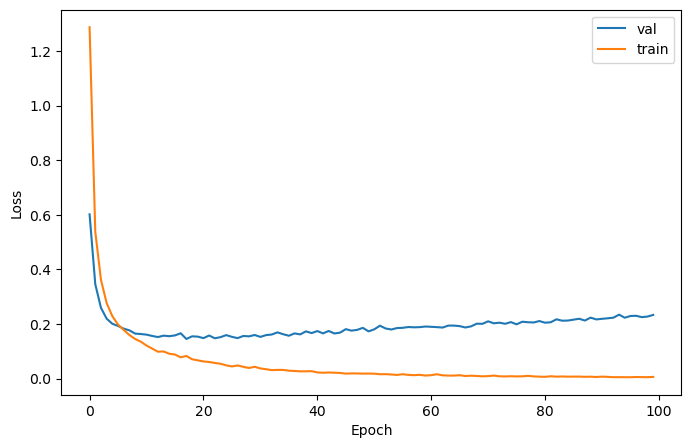

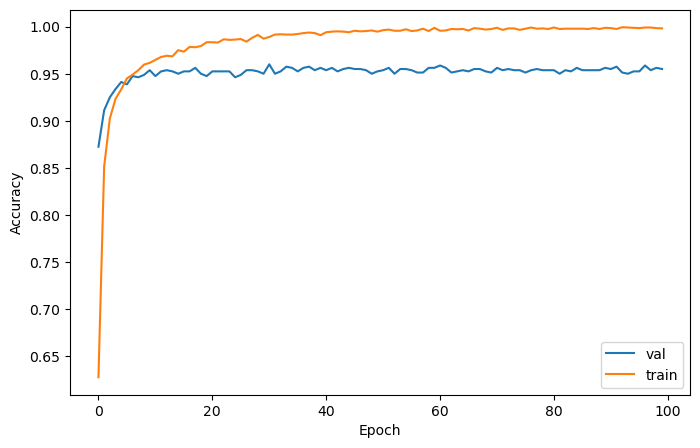

In [39]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"accuracy : {accuracy:.2f}, loss : {loss:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(history.history["val_loss"])
plt.plot(history.history["loss"])

plt.legend(["val", "train"])
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()



plt.figure(figsize=(8, 5))

plt.plot(history.history["val_accuracy"])
plt.plot(history.history["accuracy"])

plt.legend(["val", "train"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.show()

## Predictions

Using Softmax to get probabilities and finding the predicted classes.

In [40]:
prob_model = Sequential([
    model,
    keras.layers.Softmax()
])

pred = prob_model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


## Confusion Matrix

Checking the predictions using a confusion matrix.

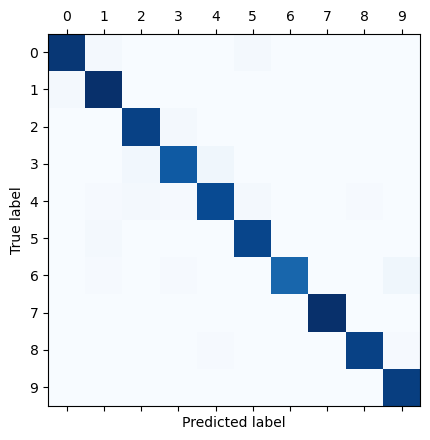

In [41]:
from sklearn.metrics import confusion_matrix

plt.matshow(confusion_matrix(y_test, pred_classes), cmap="Blues")
plt.xticks(range(10))
plt.yticks(range(10))
plt.xlabel("Predicted label")
plt.ylabel("True label");